In [1]:
import langchain
print(langchain.__version__)

1.2.7


In [2]:
from dotenv import load_dotenv
import os 
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('../../env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
if AZURE_OPENAI_API_KEY:
    print(AZURE_OPENAI_API_KEY[:10])
else:
    print("AZURE_OPENAI_API_KEY가 설정되지 않았습니다.")
print(MODEL_NAME)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_ENDPOINT'] = os.getenv('LANGCHAIN_ENDPOINT')
os.environ['LANGCHAIN_TRACING_V2'] = 'false' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'AGENT'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    langsmith_key = os.getenv('LANGSMITH_API_KEY')
    if langsmith_key and len(langsmith_key) > 0:
        print('랭스미스로 추적 중입니다 :', langsmith_key[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

FuhnkG3b81
gpt-5-nano
랭스미스로 추적 중입니다 : lsv2_pt_ef


In [3]:
import os
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    model=os.environ['MODEL_NAME'],
    azure_deployment=os.environ["MODEL_NAME"],
    azure_endpoint=os.environ["END_POINT"],
    openai_api_version="2025-03-01-preview",
    openai_api_key=os.environ["AZURE_OPENAI_API_KEY"],
)
llm.invoke("안녕!")

AIMessage(content='안녕하세요! 오늘 무엇을 도와드릴까요? 번역, 글쓰기, 요리 레시피, 코딩 문제, 정보 검색, 일정 정리 등 어떤 주제든 말씀해 주세요. 필요하시면 한국어 연습도 같이 할 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 386, 'prompt_tokens': 9, 'total_tokens': 395, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 320, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D75LhoPfOEcj85ujfGbtYrbb29CP9', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'conte

## 에이전트 만들기

기존에 있던 여러가지 에이전트 작성 함수들이 create_agent로 통합되었습니다.

이 에이전트는 랭그래프로 이루어져 있습니다.

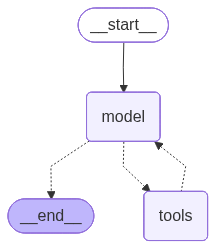

In [3]:
from langchain.agents import create_agent
from langchain.tools import tool

@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def get_weather(location: str) -> str:
    """Get weather information for a location."""
    return f"Weather in {location}: Sunny, 72°F"


agent = create_agent(
    llm,
    [get_weather],
    system_prompt="너는 도우미야. 너의 임무는 사용자의 질문에 대해 정확하고 간결하게 답변해."
)
result = agent.invoke(
    {"messages": [{"role": "user", "content": "샌프란시스코의 날씨는?"}]}
)
print(agent)
agent

In [4]:
for m in result['messages']:
    print(type(m))
    print(m.content)
    print('----------------------')

<class 'langchain_core.messages.human.HumanMessage'>
샌프란시스코의 날씨는?
----------------------
<class 'langchain_core.messages.ai.AIMessage'>

----------------------
<class 'langchain_core.messages.tool.ToolMessage'>
Weather in 샌프란시스코: Sunny, 72°F
----------------------
<class 'langchain_core.messages.ai.AIMessage'>
샌프란시스코의 현재 날씨는 화창하며 기온은 섭씨 약 22도(72°F)입니다.
----------------------


## 미들웨어(Middleware)

https://docs.langchain.com/oss/python/langchain/middleware

미들웨어는 이번 version1에서 도입된 핵심 개념 중 하나로 미들웨어는 주요 실행 루프(model 호출 → tool 호출 → 종료) 사이사이에 끼워 넣을 수 있는 매커니즘

- 모니터링: 에이전트 행동 로깅, 호출 횟수 추적, 디버깅 등. 
- 변형(Modify): 프롬프트 조작, 요청 메시지 수정, 툴 목록/모델 선택 변경 등.
- 제어(Control): 반복 제한, 조기 종료(jump), 툴 호출 허가/거부 등. 
- 강제(Enforce): 개인정보 제거(PII redaction), 토큰 제한, 보안 가드레일 적용 등.

### 다이나믹 프롬프트

In [7]:
from typing import TypedDict

from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest

class Context(TypedDict):
    user_role: str

@dynamic_prompt
def user_role_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user role."""
    user_role = request.runtime.context.get("user_role", "user")
    base_prompt = "너는 친절한 도우미다. 유저의 질문에 대해서"

    if user_role == "expert":
        return f"{base_prompt} 전문적인 답변을 하라."
    elif user_role == "beginner":
        return f"{base_prompt} 쉽게 설명하라."

    return base_prompt

agent = create_agent(
    model=llm,
    tools=[search],
    middleware=[user_role_prompt],
    context_schema=Context,
    debug=True,
)

result = agent.invoke(
    {"messages": [{"role": "user", "content": "머신러닝에 대해서 설명해줘"}]},
    context={"user_role": "expert"}
)

print('==========================================')
for m in result['messages']:
    print(type(m))
    print(m.content)
    print('----------------------')

[values] {'messages': [HumanMessage(content='머신러닝에 대해서 설명해줘', additional_kwargs={}, response_metadata={}, id='7b9fc2c7-7a70-49d5-997f-065028dd0e1c')]}
[updates] {'model': {'messages': [AIMessage(content='머신러닝(기계학습)이란 컴퓨터가 명시적으로 프로그래밍되지 않고도 데이터를 이용해 스스로 학습하고 예측 또는 결정을 내릴 수 있도록 하는 인공지능의 한 분야입니다. 즉, 컴퓨터가 경험(데이터)으로부터 패턴을 발견하고, 이를 바탕으로 새로운 데이터에 대해 일반화된 결론을 도출할 수 있게 하는 기술입니다.\n\n머신러닝은 크게 세 가지 유형으로 나눌 수 있습니다.\n\n1. 지도학습(Supervised Learning): 입력 데이터와 이에 대응하는 정답(라벨)이 주어져, 모델이 그 정답을 예측하도록 학습합니다. 예를 들어, 이메일이 스팸인지 아닌지 판별하는 문제는 지도학습입니다.\n\n2. 비지도학습(Unsupervised Learning): 정답 없이 데이터의 패턴이나 구조를 찾는 학습 방법입니다. 클러스터링(군집화)이나 차원 축소가 여기에 포함됩니다.\n\n3. 강화학습(Reinforcement Learning): 에이전트가 환경과 상호작용하면서 보상을 최대화하도록 학습합니다. 주로 게임이나 로봇 제어 분야에 사용됩니다.\n\n머신러닝은 다양한 분야에서 활용되고 있으며, 이미지 인식, 음성 인식, 자연어 처리, 추천 시스템 등 현대 인공지능 기술의 핵심 기반입니다. 필요하면 더 구체적인 설명이나 분야별 사례도 알려드릴 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 319, 'prompt_tokens': 73, 'total_tokens': 392, 'completion

### 메세지 요약 미들웨어

In [42]:
from langchain.agents.middleware  import SummarizationMiddleware

summarization_middleware = SummarizationMiddleware(
    model=llm,
    max_tokens_before_summary=100,
    messages_to_keep=4,
)
from langchain.tools import tool, ToolRuntime
from dataclasses import dataclass

SYSTEM_PROMPT = """당신은 말장난으로 대답하는 유쾌한 기상 예보 전문가입니다.

- get_weather_for_location: 사용자가 날씨를 물을 때는 이 도구를 사용하세요.
- get_user_location: 사용자가 지금 있는 곳의 장소를 얻는 도구입니다.

사용자가 날씨를 물을 때는 반드시 ‘get_weather_for_location’를 의미하는지 확인해야 하며,
만약 ‘지금 내가 있는 곳’이라면, 먼저 사용자의 위치를 찾는 도구(get_user_location)를 사용하세요."""

@dataclass
class ResponseFormat:
    """에이전트의 응답 형식"""
    punny_response: str
    weather_conditions: str | None = None

@tool
def get_weather_for_location(city: str) -> str:
    """도시의 날씨 정보를 가져오는 도구"""
    return f"It's always sunny in {city}!"

@dataclass
class Context:
    """사용자 정의 런타임 컨텍스트 스키마."""
    user_id: str

@tool
def get_user_location(runtime: ToolRuntime[Context]) -> str:
    """사용자 정보를 기반으로 사용자의 위치를 찾는 도구"""
    user_id = runtime.context.user_id
    return "Florida" if user_id == "1" else "SF"

from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

joke_agent = create_agent(
    model=llm,
    system_prompt=SYSTEM_PROMPT,
    tools=[get_user_location, get_weather_for_location],
    context_schema=Context,
    response_format=ResponseFormat,
    checkpointer=checkpointer,
    middleware=[summarization_middleware]
)



In [43]:
config = {"configurable": {"thread_id": "1"}}

joke_agent.debug = False

response = joke_agent.invoke(
    {"messages": [{"role": "user", "content": "오늘 날씨 어때?"}]},
    config=config,
    context=Context(user_id="1")
)

response = joke_agent.invoke(
    {"messages": [{"role": "user", "content": "고마워!"}]},
    config=config,
    context=Context(user_id="1")
)

response = joke_agent.invoke(
    {"messages": [{"role": "user", "content": "오늘 날씨를 색깔로 표현해줘"}]},
    config=config,
    context=Context(user_id="1")
)

In [44]:
result = joke_agent.invoke({"messages": [{"role": "user", "content": "오늘 날씨를 받아와서 아주 장황한 시를 한 편 써줘!"}]},
    config=config,
    context=Context(user_id="1")
)

for m in result['messages']:
    print(type(m))
    print(m.content)
    print('----------------------')

print(f'final answer: {result["messages"][-1].content}')

<class 'langchain_core.messages.human.HumanMessage'>
Here is a summary of the conversation to date:

User asked about today's weather in Florida and received a playful pun response indicating it is always sunny there. User thanked the assistant in Korean ("고마워!"), and the assistant replied with a cheerful Korean pun. User then requested to express today's weather as a color, to which the assistant responded that today's weather is like a bright yellow, symbolizing happiness and energy with a pun. Finally, the user requested a lengthy poem about today's weather.
----------------------
<class 'langchain_core.messages.ai.AIMessage'>

----------------------
<class 'langchain_core.messages.tool.ToolMessage'>
Florida
----------------------
<class 'langchain_core.messages.ai.AIMessage'>

----------------------
<class 'langchain_core.messages.tool.ToolMessage'>
It's always sunny in Florida!
----------------------
<class 'langchain_core.messages.ai.AIMessage'>
{"weather_conditions":"sunny","pun

## Human in the Loop (Interrupt)

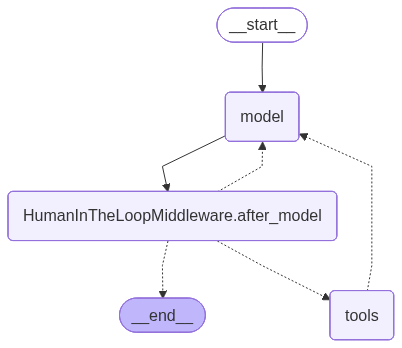

In [18]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware 
from langgraph.checkpoint.memory import InMemorySaver 

@tool
def write_file_tool(file_path: str, content: str) -> str:
    """Write content to a file."""
    with open(file_path, 'w') as f:
        f.write(content)
    return f"File {file_path} written successfully."

@tool
def read_file_tool(file_path: str) -> str:
    """Read data from a file."""
    with open(file_path, 'r') as f:
        return f.read()

agent = create_agent(
    model=llm,
    tools=[write_file_tool, read_file_tool],
    middleware=[
        HumanInTheLoopMiddleware( 
            interrupt_on={
                "write_file_tool": True,  
                "read_data_tool": False,
            },
            description_prefix="Tool execution pending approval",
        ),
    ],
    checkpointer=InMemorySaver(),  
)

agent

In [19]:
from langgraph.types import Command

# 중간에 인터럽트가 발생하고 파일이 실제로 생성되지 않는다.
cfg = {"configurable": {"thread_id": "1"}}
agent.invoke({"messages": [{"role": "user", "content": "test.txt라는 파일을 생성하고 hello world라고 적어"}]}, 
             config=cfg
             )

{'messages': [HumanMessage(content='test.txt라는 파일을 생성하고 hello world라고 적어', additional_kwargs={}, response_metadata={}, id='ba372c3c-51f4-4c84-8296-70bfb210b845'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 83, 'total_tokens': 106, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_3dcd5944f5', 'id': 'chatcmpl-CV1H1KKehC8uJDkucrAVyxifA0mW4', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'tool_calls'

In [20]:
# 정지된 지점에서 사용자가 승인을 하면 다시 실행되고 파일이 생성된다.
agent.invoke(
    Command( 
        resume={"decisions": [{"type": "approve"}]} 
    ), 
    config=config
)

{'messages': [HumanMessage(content='test.txt라는 파일을 생성하고 hello world라고 적어', additional_kwargs={}, response_metadata={}, id='ba372c3c-51f4-4c84-8296-70bfb210b845'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 83, 'total_tokens': 106, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_3dcd5944f5', 'id': 'chatcmpl-CV1H1KKehC8uJDkucrAVyxifA0mW4', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'tool_calls'

### 개인정보(Personally Identifiable Information) 관측

In [41]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware

@tool
def read_env_file(file_path: str) -> str:
    """Read data from a file."""
    with open(file_path, 'r') as f:
        return f.read()

agent = create_agent(
    model=llm,
    tools=[read_env_file],
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
        PIIMiddleware(
            "API_KEY",
            detector=r"lsv2_pt_[a-zA-Z0-9_]{30}",
            strategy="mask", #mask, block, redact
            # apply_to_output=True #주석을 풀어봅시다.
        ),
    ],
)

result = agent.invoke({"messages": [{"role": "user", "content": "'../../env' 파일에서 랭스미스 관련 정보를 출력해줘"}]})

print(result["messages"][-1].content)

'../../env' 파일 내 랭스미스 관련 정보는 다음과 같습니다:

- LANGSMITH_API_KEY=****36c239_5febe1cb3b
- LANGCHAIN_ENDPOINT="https://api.smith.langchain.com"


### 도구 재호출 관리 - ToolRetryMiddleware 

In [70]:
from langchain.agents.middleware import ToolRetryMiddleware
from langchain.tools import ToolException

from datetime import datetime
@tool
def print_time_tool(query: str) -> str:
    """Print the current time."""
    print(f">> The current time is {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}")
    raise ToolException("Error")
    return f"The current time is {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}"

prompt = "지금 시간을 출력해줘."

agent = create_agent(
    model=llm,
    tools=[print_time_tool],
    system_prompt=prompt,
    middleware=[
        ToolRetryMiddleware(
            max_retries=3,  
            initial_delay=3.0,  
            max_delay=6.0,  
        ),
    ],
)

result = await agent.ainvoke({"messages": [{"role": "user", "content": "지금 몇 시야?"}]})
for m in result['messages']:
    print(type(m))
    print(m.content)
    print('----------------------')

>> The current time is 2025-10-27 05:48:01
>> The current time is 2025-10-27 05:48:05
>> The current time is 2025-10-27 05:48:10
>> The current time is 2025-10-27 05:48:17
<class 'langchain_core.messages.human.HumanMessage'>
지금 몇 시야?
----------------------
<class 'langchain_core.messages.ai.AIMessage'>

----------------------
<class 'langchain_core.messages.tool.ToolMessage'>
Tool 'print_time_tool' failed after 4 attempts with ToolException
----------------------
<class 'langchain_core.messages.ai.AIMessage'>
현재 시간을 불러오는 데 문제가 발생했어요. 잠시 후 다시 시도해 주시겠어요?
----------------------


## DeepAgent

https://docs.langchain.com/oss/python/deepagents/overview

DeepAgents는 복잡하고 다단계의 작업을 수행할 수 있는 에이전트를 구축하기 위한 독립형 라이브러리입니다.
이 라이브러리는 LangGraph를 기반으로 하며, Claude Code, Deep Research, Manus와 같은 애플리케이션에서 영감을 받아 개발되었습니다.


In [ ]:
import os
from typing import Literal
from tavily import TavilyClient

print(os.environ["TAVILY_API_KEY"][:10])
tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )

In [7]:
from deepagents import create_deep_agent

# System prompt to steer the agent to be an expert researcher
research_instructions = """당신은 전문 연구원입니다. 당신의 역할은 철저한 조사를 수행한 후, 완성도 높은 보고서를 작성하는 것입니다.

당신은 주요 정보 수집 수단으로 인터넷 검색 도구를 사용할 수 있습니다.

##internet_search

이 도구를 사용하여 특정 쿼리에 대한 인터넷 검색을 수행할 수 있습니다.
검색 결과의 최대 개수, 주제(topic), 그리고 원시 콘텐츠(raw content)를 포함할지 여부를 지정할 수 있습니다."""

agent = create_deep_agent(
    model=llm,
    tools=[internet_search],
    system_prompt=research_instructions,
    debug=True
)

result = agent.invoke({"messages": [{"role": "user", "content": "이번에 랭체인과 랭그래프가 version 1이 되었는데 주요 변화가 뭐야?"}]})

print(result["messages"][-1].content)

[values] {'messages': [HumanMessage(content='이번에 랭체인과 랭그래프가 version 1이 되었는데 주요 변화가 뭐야?', additional_kwargs={}, response_metadata={}, id='81a02ab4-346e-4ced-b76f-8b6e095121aa')]}
[updates] {'FilesystemMiddleware.before_agent': None}
[updates] {'PatchToolCallsMiddleware.before_agent': {'messages': [RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='__remove_all__'), HumanMessage(content='이번에 랭체인과 랭그래프가 version 1이 되었는데 주요 변화가 뭐야?', additional_kwargs={}, response_metadata={}, id='81a02ab4-346e-4ced-b76f-8b6e095121aa')]}}
[values] {'messages': [HumanMessage(content='이번에 랭체인과 랭그래프가 version 1이 되었는데 주요 변화가 뭐야?', additional_kwargs={}, response_metadata={}, id='81a02ab4-346e-4ced-b76f-8b6e095121aa')]}
[updates] {'SummarizationMiddleware.before_model': None}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 4084, 'total_tokens': 4150, 'completion_tokens_de